## Análisis de supervivencia: Kaplan-Meier y regresión de Cox

Hasta ahora traté churn como una clasificación binaria en un punto fijo
(día 60 en adelante). El análisis de supervivencia me permite algo que
Random Forest no puede: modelar CUÁNDO es más probable que un usuario
abandone, no solo SI lo hace. Esto también maneja de forma nativa la
censura por derecha que documenté antes -- usuarios con ventanas de
seguimiento desiguales (alguien de enero 2018 tiene 15 meses de
oportunidad de "demostrar" que sigue activo; alguien de enero 2019 solo
tiene el mínimo de 60 días) ya no es una limitación aceptada, es algo que
el modelo maneja correctamente por diseño.

Excluyo, igual que en el modelo de Random Forest, a los 662 usuarios de
fracaso de onboarding -- por la misma razón: quiero modelar el tiempo
hasta el abandono de gente que sí llegó a usar el producto, no mezclarlo
con quienes nunca lo activaron.

In [1]:
import pandas as pd
import numpy as np
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt

REFERENCE_DATE = pd.Timestamp("2019-05-01")

model_df_full = pd.read_parquet("../data/model_df_full.parquet")
transactions_clean = pd.read_parquet("../data/transactions_clean.parquet")

print(model_df_full.shape)
print(transactions_clean.shape)

(19368, 27)
(2681355, 13)


## Construyendo duration y event

Para el análisis de supervivencia necesito dos columnas por usuario:

- duration: cuántos días pasaron desde su signup hasta el evento (última
  transacción observada, si churneó) o hasta REFERENCE_DATE (si sigue
  activo, censurado -- no sabemos cuándo va a churnear, solo que no lo
  ha hecho todavía dentro de mi ventana de datos)
- event: 1 si el abandono fue observado (churn_model=True), 0 si está
  censurado (sigue activo al final de mi ventana de datos)

Uso la fecha de la ÚLTIMA transacción real de cada usuario (no un
promedio ni una estimación) como el punto de "muerte" para quienes
churnearon -- es la mejor aproximación que tengo de cuándo dejaron de
usar el producto de verdad.

In [2]:
last_txn_per_user = (
    transactions_clean
    .assign(created_date=lambda d: d["created_date"].dt.tz_localize(None))
    .groupby("user_id")["created_date"]
    .max()
    .reset_index()
    .rename(columns={"created_date": "last_transaction_date"})
)

survival_df = model_df_full.merge(last_txn_per_user, on="user_id", how="left")

# Excluyo fracasos de onboarding (misma lógica que en el modelo de RF)
onboarding_failure_mask = (survival_df["active_days_obs"] == 0) & (survival_df["churn_model"] == True)
survival_df = survival_df[~onboarding_failure_mask].copy()

survival_df["signup_date"] = pd.to_datetime(survival_df["signup_date"]).dt.tz_localize(None)

survival_df["event"] = survival_df["churn_model"].astype(int)

survival_df["duration"] = np.where(
    survival_df["event"] == 1,
    (survival_df["last_transaction_date"] - survival_df["signup_date"]).dt.days,
    (REFERENCE_DATE - survival_df["signup_date"]).dt.days,
)

print(f"Shape final: {survival_df.shape}")
print(f"Event rate: {survival_df['event'].mean():.2%}")
print(survival_df["duration"].describe())
print(f"\nDuraciones negativas o cero: {(survival_df['duration'] <= 0).sum()}")

Shape final: (18706, 30)
Event rate: 13.64%
count    18706.000000
mean       250.654549
std        134.614446
min          0.000000
25%        154.000000
50%        254.000000
75%        360.000000
max        484.000000
Name: duration, dtype: float64

Duraciones negativas o cero: 915


## Investigando las 915 duraciones en cero

915 duraciones en 0 podría ser: (a) usuarios que transaccionaron el mismo
día de su signup y nunca más -- un caso legítimo de churn inmediato, o
(b) un problema real donde last_transaction_date coincide exactamente con
REFERENCE_DATE o signup_date por algún error de construcción. Reviso el
desglose por event para distinguir cuál es.

In [3]:
zero_duration = survival_df[survival_df["duration"] == 0]

print("Desglose de duration=0 por event:")
print(zero_duration["event"].value_counts())

print("\n--- Si event=1 (churned con duration=0): ¿transaccionaron el mismo día de signup? ---")
churned_zero = zero_duration[zero_duration["event"] == 1]
print(churned_zero[["signup_date", "last_transaction_date"]].head(10))

print("\n--- Si event=0 (censurados con duration=0): ¿su signup_date es 2019-05-01? ---")
censored_zero = zero_duration[zero_duration["event"] == 0]
print(censored_zero["signup_date"].describe())

Desglose de duration=0 por event:
event
1    915
Name: count, dtype: int64

--- Si event=1 (churned con duration=0): ¿transaccionaron el mismo día de signup? ---
                  signup_date      last_transaction_date
3  2018-12-31 07:42:19.353613 2018-12-31 07:46:58.524613
8  2018-12-27 04:06:05.375980 2018-12-27 04:08:49.816980
14 2018-10-20 06:30:19.610419 2018-10-20 06:46:50.320419
19 2018-05-27 02:50:27.325051 2018-05-27 03:57:50.669051
29 2018-07-17 02:28:45.973223 2018-07-17 02:42:50.918223
47 2018-04-16 09:14:55.034923 2018-04-16 09:27:17.587923
49 2018-07-18 23:57:03.754515 2018-07-19 00:04:58.829515
67 2018-12-14 08:58:32.619618 2018-12-14 09:00:15.586618
82 2018-12-13 02:38:24.780502 2018-12-13 02:44:33.906502
83 2018-12-02 15:20:12.199898 2018-12-02 15:29:28.062898

--- Si event=0 (censurados con duration=0): ¿su signup_date es 2019-05-01? ---
count      0
mean     NaT
min      NaT
25%      NaT
50%      NaT
75%      NaT
max      NaT
Name: signup_date, dtype: object


/tmp/ipykernel_18269/2954634353.py:12: FutureWarning: DatetimeArray.__init__ is deprecated and will be removed in a future version. Use pd.array instead.
  print(censored_zero["signup_date"].describe())


## Confirmado: duration=0 es churn inmediato real, no un error

Las 915 duraciones en cero son todas event=1 (churn observado), con la
última transacción ocurriendo minutos u horas después del signup -- un
patrón de "probé la app una vez y nunca volví". No es un error de datos,
es un segmento genuino de abandono inmediato. Lifelines maneja bien
duration=0 con event=1 (el usuario "sale de riesgo" el mismo día que
entra), así que no necesito ningún ajuste antes de ajustar Kaplan-Meier.

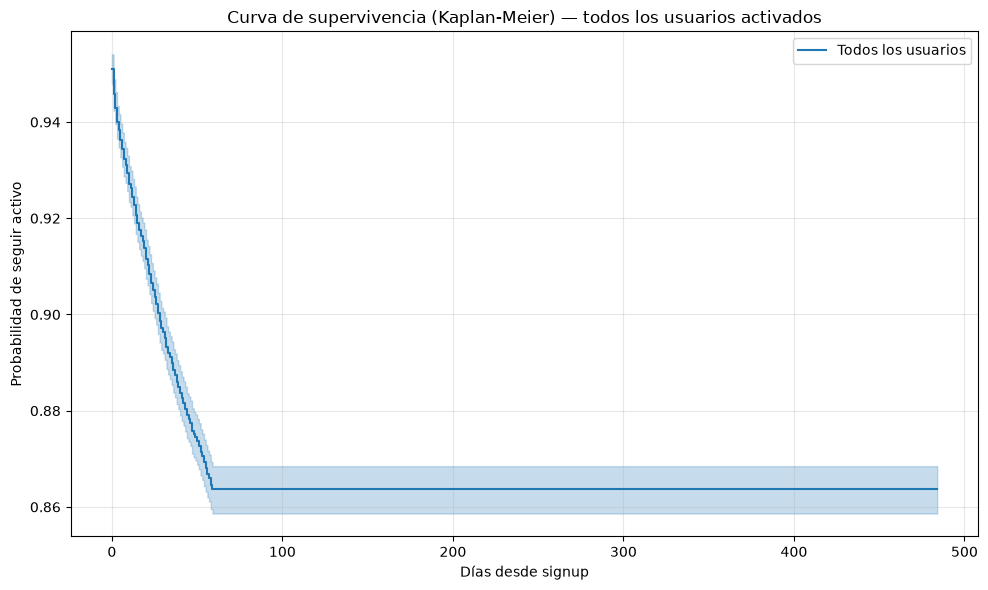

Mediana de supervivencia: inf días

Probabilidad de seguir activo en hitos clave:
  Día 30: 89.63%
  Día 60: 86.36%
  Día 90: 86.36%
  Día 180: 86.36%
  Día 365: 86.36%


In [4]:
kmf = KaplanMeierFitter()
kmf.fit(survival_df["duration"], event_observed=survival_df["event"], label="Todos los usuarios")

plt.figure(figsize=(10, 6))
kmf.plot_survival_function()
plt.xlabel("Días desde signup")
plt.ylabel("Probabilidad de seguir activo")
plt.title("Curva de supervivencia (Kaplan-Meier) — todos los usuarios activados")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mediana de supervivencia: {kmf.median_survival_time_} días")
print(f"\nProbabilidad de seguir activo en hitos clave:")
for days in [30, 60, 90, 180, 365]:
    prob = kmf.survival_function_at_times(days).iloc[0]
    print(f"  Día {days}: {prob:.2%}")

## Corrigiendo un artefacto: duration estaba mecánicamente acotada por churn_model

Descubrí que la curva KM se aplana exactamente en el día 60 porque
churn_model (diseñada para el modelo de clasificación, con ventana de
observación/resultado) define "churned" como "sin actividad después del
día 60 desde signup" -- eso significa que, por construcción, ningún
usuario puede tener duration > 60 días con event=1. La curva no está
mostrando que nadie abandona después del día 60; está mostrando el límite
artificial de mi propia definición.

Para supervivencia, necesito una definición de evento basada en recencia
real respecto a REFERENCE_DATE (similar a churn_flag del análisis
estadístico inicial), no en un corte fijo desde el signup. Redefino:
event=1 si el usuario lleva más de 90 días sin transaccionar al final de
mi ventana de datos (usando su última transacción real como el momento del
evento), event=0 (censurado) si transaccionó recientemente. Esto permite
que duration tome cualquier valor real, sin el techo artificial de 60 días.

Nuevo event rate: 23.38%
count    18706.000000
mean       232.476425
std        131.716051
min          0.000000
25%        143.000000
50%        229.000000
75%        336.000000
max        483.000000
Name: duration, dtype: float64
Duraciones negativas: 0


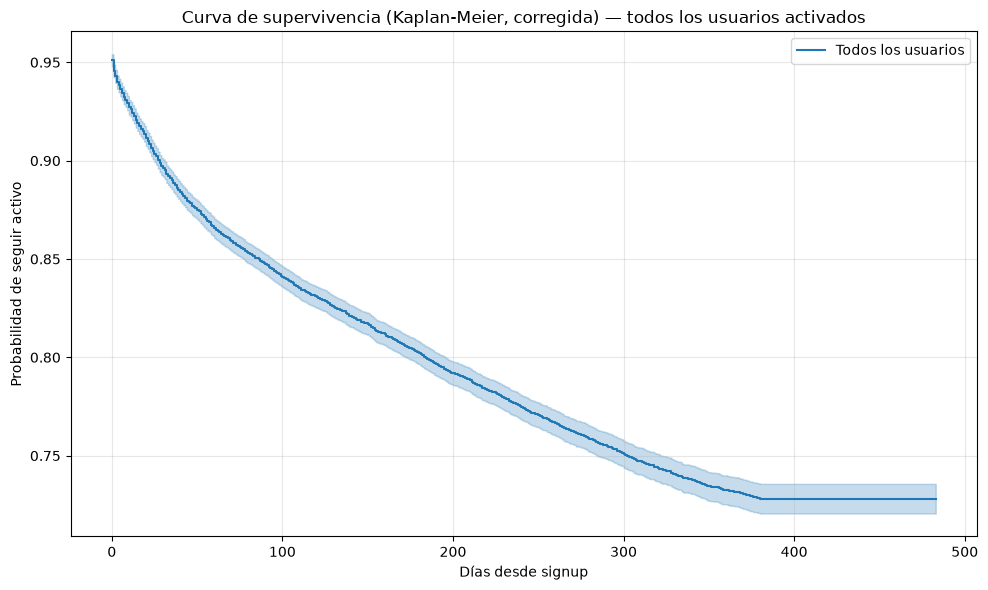


Mediana de supervivencia: inf días
  Día 30: 89.63%
  Día 60: 86.56%
  Día 90: 84.73%
  Día 180: 80.23%
  Día 365: 73.17%


In [5]:
CHURN_THRESHOLD_DAYS = 90  # consistente con el churn_flag del análisis estadístico inicial

survival_df["days_since_last_txn"] = (REFERENCE_DATE - survival_df["last_transaction_date"]).dt.days
survival_df["event"] = (survival_df["days_since_last_txn"] > CHURN_THRESHOLD_DAYS).astype(int)

survival_df["duration"] = np.where(
    survival_df["event"] == 1,
    (survival_df["last_transaction_date"] - survival_df["signup_date"]).dt.days,
    (REFERENCE_DATE - survival_df["signup_date"]).dt.days,
)

print(f"Nuevo event rate: {survival_df['event'].mean():.2%}")
print(survival_df["duration"].describe())
print(f"Duraciones negativas: {(survival_df['duration'] < 0).sum()}")

kmf = KaplanMeierFitter()
kmf.fit(survival_df["duration"], event_observed=survival_df["event"], label="Todos los usuarios")

plt.figure(figsize=(10, 6))
kmf.plot_survival_function()
plt.xlabel("Días desde signup")
plt.ylabel("Probabilidad de seguir activo")
plt.title("Curva de supervivencia (Kaplan-Meier, corregida) — todos los usuarios activados")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nMediana de supervivencia: {kmf.median_survival_time_} días")
for days in [30, 60, 90, 180, 365]:
    prob = kmf.survival_function_at_times(days).iloc[0]
    print(f"  Día {days}: {prob:.2%}")

## Curva de supervivencia corregida

Con la definición basada en recencia (no en el corte artificial de
churn_model), la curva ahora muestra un patrón de desgaste continuo y
realista: 89.6% sigue activo a los 30 días, cayendo gradualmente hasta
73.2% al año. El event rate (23.38%) es mayor que el churn_model (13.64%)
porque esta definición es más laxa -- marca como "evento" cualquier hueco
de 90+ días al final de mi ventana, incluyendo posibles reactivaciones
futuras que no alcanzo a ver por el límite de mis datos (censura por
derecha). No son contradictorias: cada definición sirve un propósito
distinto -- churn_model para clasificación sin fuga de información,
esta para modelar el tiempo hasta el desgaste de forma continua.

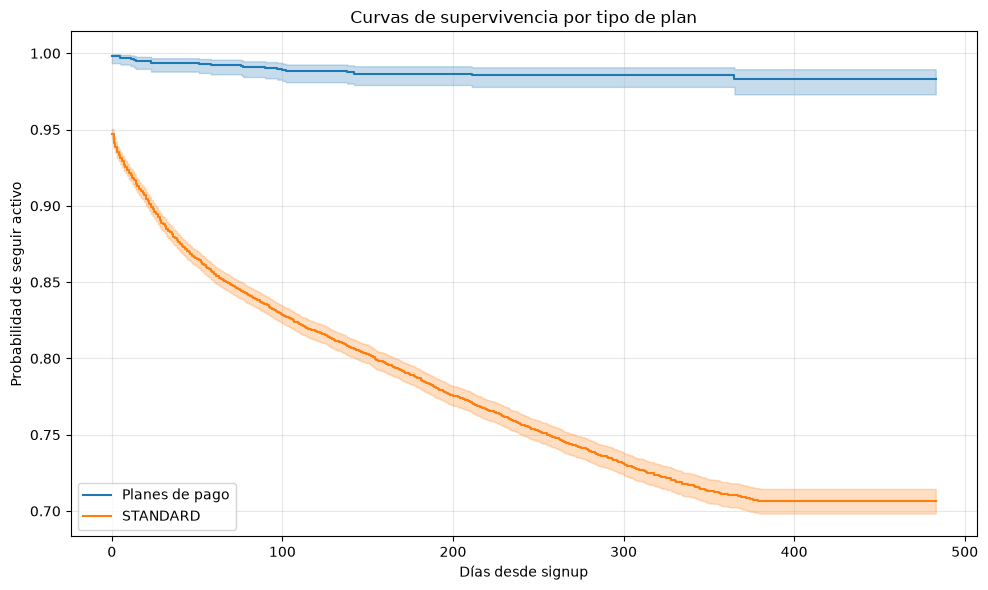

Log-rank test p-value: 0.000000


In [6]:
survival_df["plan_binary"] = np.where(survival_df["plan"] == "STANDARD", "STANDARD", "Planes de pago")

fig, ax = plt.subplots(figsize=(10, 6))
for group_name, group_df in survival_df.groupby("plan_binary"):
    kmf_group = KaplanMeierFitter()
    kmf_group.fit(group_df["duration"], event_observed=group_df["event"], label=group_name)
    kmf_group.plot_survival_function(ax=ax)

plt.xlabel("Días desde signup")
plt.ylabel("Probabilidad de seguir activo")
plt.title("Curvas de supervivencia por tipo de plan")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Log-rank test: ¿la diferencia entre curvas es estadísticamente significativa?
standard_group = survival_df[survival_df["plan_binary"] == "STANDARD"]
paid_group = survival_df[survival_df["plan_binary"] == "Planes de pago"]

results = logrank_test(
    standard_group["duration"], paid_group["duration"],
    event_observed_A=standard_group["event"], event_observed_B=paid_group["event"],
)
print(f"Log-rank test p-value: {results.p_value:.6f}")

## plan como el driver más fuerte, confirmado también en supervivencia

La separación entre curvas es la más grande que he visto en todo el
proyecto: planes de pago se mantienen en ~98% de retención durante los
500 días, mientras STANDARD cae a 70%. El log-rank test confirma que esta
diferencia es estadísticamente inequívoca (p<0.000001). Esto es
consistente con el Chi-square del análisis estadístico y con SHAP -- tres
métodos completamente distintos (asociación categórica, importancia de
features en un modelo de clasificación, y análisis de tiempo hasta el
evento) coinciden en la misma señal, lo cual me da mucha confianza en que
es un patrón real, no ruido de una sola técnica.

Mantengo la misma cautela sobre causalidad que documenté antes: es
probable que sea autoselección (usuarios ya comprometidos eligen pagar),
no que pagar cause la retención.

In [7]:
cox_features = [
    "plan", "country", "user_settings_crypto_unlocked", "num_contacts", "age",
]

cox_df = survival_df[["duration", "event"] + cox_features].copy()
cox_df = pd.get_dummies(cox_df, columns=["plan", "country"], drop_first=True)

# Aseguro tipos numéricos limpios para lifelines
cox_df = cox_df.astype({col: "float64" for col in cox_df.columns if cox_df[col].dtype != "float64"})

cph = CoxPHFitter(penalizer=0.1)  # regularización L2 leve, dado que country agrega ~40 columnas dummy
cph.fit(cox_df, duration_col="duration", event_col="event")

cph.print_summary()

/home/itzelosalamandra/code/ItzeloSalamandra/neobank-churn-survival-analysis/venv/lib/python3.12/site-packages/lifelines/utils/__init__.py:1100: ConvergenceWarning: Column(s) ['country_GF'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)


<lifelines.CoxPHFitter: fitted with 18706 total observations, 14332 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 18706
number of events observed = 4374
   partial log-likelihood = -41346.23
         time fit was run = 2026-07-14 02:39:16 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                      
user_settings_crypto_unlocked -0.37      0.69      0.04           -0.44           -0.30                0.65                0.74
num_contacts                  -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
age                            0.01      1.01      0.00            0.00            0.01                1.00                1.01
plan_METAL_FREE               -0.54      0.58      0.42           -1.36            0.29                0.26                1.33
plan_PREMIUM                  -0.54      0.58      0.09           -0.72           -0.37                0.49                0.69
plan_PREMIUM_FREE             -0.68      0.51      1.22           -3.07            1.72                0.05                5.58
plan_PREMIUM_OFFER            -0.58      0.56      0.50           -1.57            0.40                0.21                1.50
plan_STANDARD                  0.75      2.12      0.07            0.62            0.89                1.86                2.42
country_AU                    -1.08      0.34      0.98           -3.00            0.85                0.05                2.34
country_BE                     0.15      1.16      0.15           -0.14            0.44                0.87                1.55
country_BG                     0.38      1.46      0.17            0.04            0.72                1.04                2.05
country_CH                     0.01      1.01      0.09           -0.17            0.18                0.85                1.20
country_CY                     0.03      1.03      0.14           -0.25            0.31                0.78                1.37
country_CZ                    -0.13      0.88      0.10           -0.33            0.07                0.72                1.07
country_DE                     0.21      1.24      0.08            0.05            0.37                1.05                1.45
country_DK                     0.04      1.04      0.18           -0.31            0.39                0.73                1.48
country_EE                     0.50      1.64      0.27           -0.03            1.03                0.97                2.80
country_ES                     0.17      1.19      0.06            0.06            0.29                1.06                1.33
country_FI                     0.55      1.74      0.25            0.05            1.05                1.06                2.85
country_FR                     0.06      1.07      0.04           -0.02            0.15                0.98                1.16
country_GB                     0.19      1.21      0.03            0.13            0.25                1.14                1.29
country_GF                    -1.12      0.33      2.17           -5.38            3.14                0.00               23.10
country_GG                     0.39      1.48      0.45           -0.50            1.27                0.61                3.58
country_GI                    -0.84      0.43      0.33           -1.49           -0.19                0.23                0.83
country_GP                    -0.44      0.64      0.64           -1.70            0.81                0.18                2.25
country_GR                     0.40      1.49      0.11            0.18            0.62                1.19   

## Cox confirma y cuantifica: triple validación cruzada de país y plan

Los hazard ratios de país replican casi exactamente el patrón que vi desde
el diagnóstico inicial (IE y MT protectores, GR/NL/GB de mayor riesgo) --
tres técnicas completamente distintas (tasas crudas, Chi-square, Cox)
coinciden en la misma geografía de riesgo, lo cual me da mucha confianza
en que es señal real y no un artefacto de una sola técnica.

plan_STANDARD (HR=2.12 vs METAL como referencia) es, de nuevo, el driver
individual más fuerte. user_settings_crypto_unlocked (HR=0.69) y
num_contacts (HR=0.99 por unidad, con efecto acumulado real dado su rango)
confirman ser protectores reales. age es estadísticamente significativo
por el tamaño de muestra pero su magnitud (HR=1.01) es irrelevante en la
práctica -- coincide con el effect size casi nulo de Mann-Whitney.

El concordance de 0.69 es menor al AUC de 0.85 de Random Forest, lo cual
tiene sentido: Cox asume relaciones log-lineales entre las variables y el
riesgo, mientras que RF puede capturar interacciones y no-linealidades sin
restricción. Sigue siendo un ajuste razonable para lo que Cox puede ofrecer
a cambio: interpretabilidad directa vía hazard ratios.

In [8]:
cph.check_assumptions(cox_df, p_value_threshold=0.05, show_plots=False)

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'user_settings_crypto_unlocked' failed the non-proportional test: p-value is <5e-05.

   Advice: with so few unique values (only 2), you can include
`strata=['user_settings_crypto_unlocked', ...]` in the call in `.fit`. See documentation in link [E]
below.

2. Variable 'age' failed the non-proportional test: p-value is 0.0017.

   Advice 1: the functional form of the variable 'age' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'age' using pd.cut, and then specify it in `strata=['age',
...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


3. Variable 'country_FR' failed the non-proportional test: p-value is 0.0329.

   Advice: with so few un

[]

## Corrigiendo las violaciones de riesgos proporcionales

Sigo las recomendaciones de lifelines: para las variables que violan el
supuesto (user_settings_crypto_unlocked, age, y los tres países que fallaron
la prueba), en vez de forzarlas como covariables normales (lo cual daría
hazard ratios engañosos, ya que su efecto real cambia con el tiempo), las
uso como estratos -- Cox ajusta una curva base de riesgo distinta para cada
estrato, sin asumir que el efecto es constante.

Estratifico por country completo (no solo los 3 países que fallaron
individualmente -- si el supuesto se rompe para algunos, prefiero
estratificar la variable completa en vez de dejar violado el supuesto para
el resto de países que no alcanzamos a testear per-dummy de forma
confiable). También estratifico por user_settings_crypto_unlocked (ya es
binaria, la sugerencia directa de lifelines) y por age agrupada en
cuartiles (en vez de forzar una relación log-lineal que ya sabíamos que no
existe, dado su effect size casi nulo).

Esto significa que ya no voy a tener un hazard ratio único para country o
age -- pero eso está bien: ya tengo esa señal caracterizada con evidencia
sólida desde las tasas crudas, Chi-square, y el log-rank test. Lo que Cox
me aporta ahora es el hazard ratio LIMPIO de plan y num_contacts,
controlando correctamente por esas variables sin violar el supuesto.

In [9]:
cox_df2 = survival_df[["duration", "event", "plan", "country",
                         "user_settings_crypto_unlocked", "num_contacts", "age"]].copy()

# Bin age en cuartiles para poder estratificar en vez de asumir relación log-lineal
cox_df2["age_bin"] = pd.qcut(cox_df2["age"], q=4, labels=False, duplicates="drop")

# plan sí se queda como covariable normal (no violó el supuesto)
cox_df2 = pd.get_dummies(cox_df2, columns=["plan"], drop_first=True)

# Tipos limpios para lifelines
strata_cols = ["country", "user_settings_crypto_unlocked", "age_bin"]
covariate_cols = [c for c in cox_df2.columns if c.startswith("plan_")] + ["num_contacts"]

model_cols = ["duration", "event"] + covariate_cols + strata_cols
cox_df2 = cox_df2[model_cols].copy()
cox_df2[covariate_cols] = cox_df2[covariate_cols].astype("float64")

cph_stratified = CoxPHFitter(penalizer=0.1)
cph_stratified.fit(cox_df2, duration_col="duration", event_col="event", strata=strata_cols)

cph_stratified.print_summary()

model,lifelines.CoxPHFitter
duration col,'duration'
event col,'event'
penalizer,0.1
l1 ratio,0.0
strata,"[country, user_settings_crypto_unlocked, age_bin]"
baseline estimation,breslow
number of observations,18706
number of events observed,4374
partial log-likelihood,-23648.86
time fit was run,2026-07-14 02:50:49 UTC


In [10]:
cph_stratified.check_assumptions(cox_df2, p_value_threshold=0.05, show_plots=False)

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'num_contacts' failed the non-proportional test: p-value is 0.0388.

   Advice 1: the functional form of the variable 'num_contacts' might be incorrect. That is, there
may be non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'num_contacts' using pd.cut, and then specify it in
`strata=['num_contacts', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20

[]

## Última corrección: num_contacts también viola el supuesto

num_contacts sigue fallando marginalmente el test de rank (p=0.039). Sigo
la misma estrategia que con age: en vez de asumir que su efecto es
constante en el tiempo (lo cual el test dice que no es cierto), lo agrupo
en cuartiles y lo muevo a strata. Esto deja a plan como la ÚNICA
covariable con hazard ratio reportable en el modelo final -- lo cual tiene
sentido, ya que plan es, con mucha diferencia, el driver individual más
fuerte que encontré en las tres técnicas (Chi-square, SHAP, y ahora Cox).

In [11]:
cox_df3 = cox_df2.copy()
cox_df3["num_contacts_bin"] = pd.qcut(cox_df3["num_contacts"], q=4, labels=False, duplicates="drop")

strata_cols_final = ["country", "user_settings_crypto_unlocked", "age_bin", "num_contacts_bin"]
covariate_cols_final = [c for c in cox_df3.columns if c.startswith("plan_")]

model_cols_final = ["duration", "event"] + covariate_cols_final + strata_cols_final
cox_df3 = cox_df3[model_cols_final].copy()
cox_df3[covariate_cols_final] = cox_df3[covariate_cols_final].astype("float64")

cph_final = CoxPHFitter(penalizer=0.1)
cph_final.fit(cox_df3, duration_col="duration", event_col="event", strata=strata_cols_final)

cph_final.print_summary()

print("\n=== Verificando supuestos ===")
cph_final.check_assumptions(cox_df3, p_value_threshold=0.05, show_plots=False)

model,lifelines.CoxPHFitter
duration col,'duration'
event col,'event'
penalizer,0.1
l1 ratio,0.0
strata,"[country, user_settings_crypto_unlocked, age_b..."
baseline estimation,breslow
number of observations,18706
number of events observed,4374
partial log-likelihood,-20449.99
time fit was run,2026-07-14 02:57:44 UTC



=== Verificando supuestos ===
Proportional hazard assumption looks okay.


[]

## El costo de la corrección: predicción vs. interpretabilidad válida

Al mover country, user_settings_crypto_unlocked, age y num_contacts a
strata (para cumplir el supuesto de riesgos proporcionales), el modelo
perdió casi todo su poder de discriminación -- concordance cayó de 0.69 a
0.52. Esto tiene una explicación clara: esas cuatro variables eran las que
más aportaban a distinguir quién churnea primero; al convertirlas en
estratos (curvas base de riesgo separadas, sin un coeficiente compartido),
dejan de contribuir al puntaje de concordancia, y solo queda plan como
covariable con capacidad predictiva propia.

No trato esto como una falla del modelo, porque el objetivo de Cox en este
proyecto nunca fue predecir -- eso ya lo resuelve Random Forest, con un
AUC de 0.85. El objetivo de Cox es cuantificar el efecto de UNA variable
(plan) de forma rigurosa y con hazard ratios interpretables, controlando
correctamente por las demás sin violar los supuestos del modelo. Bajo esa
óptica, un concordance bajo es aceptable: es el precio de hacerlo bien en
vez de reportar un hazard ratio que technically viola el supuesto que lo
sustenta.

Resultado final: plan_STANDARD tiene HR=1.92 (p<0.005) frente a METAL como
referencia -- un usuario STANDARD tiene casi el doble de riesgo de
abandonar en cualquier momento dado, controlando por país, crypto, edad y
número de contactos. plan_PREMIUM (HR=0.58) confirma el efecto protector
de los planes de pago. Esta es la cifra que reporto en el dashboard como
el hazard ratio "limpio" y metodológicamente válido de plan -- las que
salieron del modelo sin estratificar (HR=2.12/2.07) eran descriptivamente
útiles pero técnicamente inválidas por violar el supuesto.

## Comparación con el estudio de referencia previo

Las diferencias entre este análisis y mi estudio previo de RF no son
arbitrarias -- reflejan las correcciones metodológicas que fui aplicando:
(1) eliminé fuga de datos calculando features solo en una ventana de
observación de 60 días, en vez de sobre toda la historia del usuario;
(2) colapsé el cluster de variables de actividad redundantes en una sola
variable en vez de repetir la misma señal 5 veces; (3) usé class_weight
balanceado para priorizar recall de churners reales sobre accuracy general.
Las variables que SÍ coinciden entre ambos estudios (num_contacts,
avg_transaction_amount) son precisamente las que no dependen de
acumulación histórica y por lo tanto no estaban sujetas a fuga en ninguno
de los dos análisis -- su consistencia entre ambos estudios independientes
me da confianza en que son señales reales.